# Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
#import itertoolsza

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

# Modeling Weekly Rat Sightings in Staten Island

## Importing the Data

In [ ]:
# set up the time series split
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=4)


rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-06 and after 2025-03-02.
rs = rs[rs['created_date'].between('2020-01-06', '2025-03-02')] #changed dates slightly to obtain whole weeks. Monday - Sunday

## Restrict to STATEN ISLAND

rs = rs[rs['borough']=='STATEN ISLAND']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

rs

,created_date,count
27,2020-01-06,4
32,2020-01-07,2
41,2020-01-09,1
54,2020-01-12,2
59,2020-01-13,3
...,...,...
8907,2025-02-24,3
8912,2025-02-25,1
8917,2025-02-26,1
8926,2025-02-28,2


  created_date  weekly_avg
0   2020-01-12    2.250000
1   2020-01-19    1.500000
2   2020-01-26    1.333333
3   2020-02-02    2.000000
4   2020-02-09    1.500000
5   2020-02-16    3.000000
6   2020-02-23    2.500000
7   2020-03-01    2.400000
8   2020-03-08    2.000000
9   2020-03-15    3.200000

Shape: (269, 2)
Date range: 2020-01-12 00:00:00 → 2025-03-02 00:00:00

--- Summary Statistics ---
count    269.00
mean       2.34
std        0.94
min        0.00
25%        1.67
50%        2.25
75%        3.00
max        7.00
Name: weekly_avg, dtype: float64


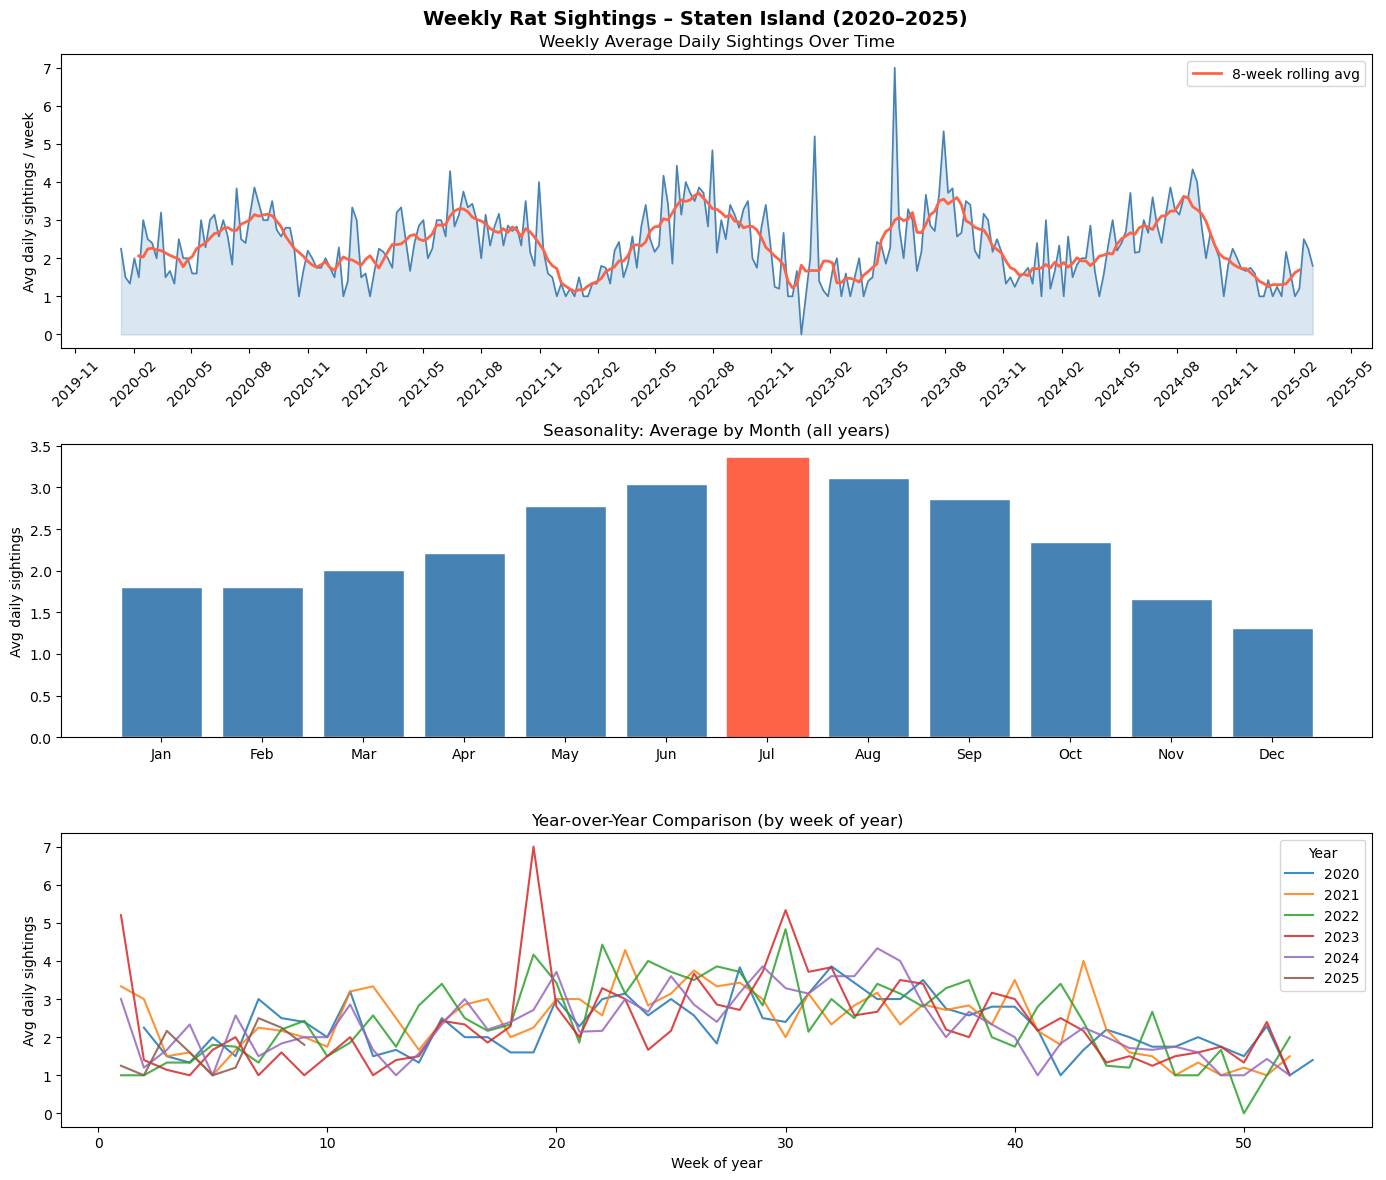


--- Year-over-Year Averages ---
      mean  median   max  min
year                         
2020  2.31    2.29  3.86  1.0
2021  2.42    2.37  4.29  1.0
2022  2.42    2.41  4.83  0.0
2023  2.36    2.17  7.00  1.0
2024  2.32    2.22  4.33  1.0
2025  1.64    1.60  2.50  1.0


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Weekly resampling ---
rs_weekly = (
    rs.set_index('created_date')
      .resample('W')['count']
      .mean()
      .fillna(0)
      .reset_index()
      .rename(columns={'count': 'weekly_avg'})
)

print(rs_weekly.head(10))
print(f"\nShape: {rs_weekly.shape}")
print(f"Date range: {rs_weekly['created_date'].min()} → {rs_weekly['created_date'].max()}")
print("\n--- Summary Statistics ---")
print(rs_weekly['weekly_avg'].describe().round(2))

# --- Add time features ---
rs_weekly['year']  = rs_weekly['created_date'].dt.year
rs_weekly['month'] = rs_weekly['created_date'].dt.month
rs_weekly['week_of_year'] = rs_weekly['created_date'].dt.isocalendar().week.astype(int)
rs_weekly['iso_year'] = rs_weekly['created_date'].dt.isocalendar().year.astype(int)  


# --- Plot 1: Full time series ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Weekly Rat Sightings – Staten Island (2020–2025)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(rs_weekly['created_date'], rs_weekly['weekly_avg'], color='steelblue', linewidth=1.2)
ax.fill_between(rs_weekly['created_date'], rs_weekly['weekly_avg'], alpha=0.2, color='steelblue')
rolling = rs_weekly['weekly_avg'].rolling(8, center=True).mean()
ax.plot(rs_weekly['created_date'], rolling, color='tomato', linewidth=2, label='8-week rolling avg')
ax.set_title('Weekly Average Daily Sightings Over Time')
ax.set_ylabel('Avg daily sightings / week')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Seasonality ---
ax2 = axes[1]
monthly_avg = rs_weekly.groupby('month')['weekly_avg'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars = ax2.bar(month_names, monthly_avg.values, color='steelblue', edgecolor='white')
ax2.set_title('Seasonality: Average by Month (all years)')
ax2.set_ylabel('Avg daily sightings')
bars[monthly_avg.idxmax() - 1].set_color('tomato')

# --- Plot 3: Year-over-year ---
ax3 = axes[2]
for year, grp in rs_weekly.groupby('iso_year'):  # <-- change year to iso_year
    grp = grp.sort_values('week_of_year')         # <-- ensure weeks are in order
    ax3.plot(grp['week_of_year'], grp['weekly_avg'], label=str(year), linewidth=1.5, alpha=0.85)
ax3.set_title('Year-over-Year Comparison (by week of year)')
ax3.set_xlabel('Week of year')
ax3.set_ylabel('Avg daily sightings')
ax3.legend(title='Year')

plt.tight_layout()
plt.savefig('rat_sightings_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Year-over-Year Averages ---")
print(rs_weekly.groupby('year')['weekly_avg'].agg(['mean','median','max','min']).round(2))

In [5]:
## There are 269 weeks from 2020-01-05 to 2025-03-02 inclusive. Confirm we have the correct number.
#rs_weekly.tail()
len(rs_weekly)

269

## Baseline Seasonal Average Model

In [6]:
years_back_use = 4
week_window_use = 1



In [7]:
def seasonal_average_forecast_weekly(data, target_dates, years_back=years_back_use, week_window=week_window_use):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["iso_week"] = df["created_date"].dt.isocalendar().week.astype(int)
    df["iso_year"] = df["created_date"].dt.isocalendar().year.astype(int)

    forecasts = []
    for target_date in target_dates:
        target_week = target_date.isocalendar()[1]   # ISO week number
        target_year = target_date.isocalendar()[0]   # ISO year
        mask = (
            (df["iso_year"] >= target_year - years_back) &
            (df["iso_year"] < target_year) &
            (np.abs(df["iso_week"] - target_week) <= week_window)
        )
        forecasts.append(df.loc[mask, "weekly_avg"].mean())
    return pd.Series(forecasts, index=target_dates)

In [8]:
results = []

rs_weekly["created_date"] = pd.to_datetime(rs_weekly["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    
    # Target dates = the weeks we want to forecast
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data
    y_pred = seasonal_average_forecast_weekly(data=train, target_dates=target_dates, 
                                              years_back=years_back_use, week_window=week_window_use)

    # True values
    y_true = test["weekly_avg"].values   # <-- changed from "count"
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i, "rmse": rmse, "mape": mape})

baseline_results_weekly_df = pd.DataFrame(results)
baseline_results_weekly_df.loc["mean"] = ["mean", baseline_results_weekly_df["rmse"].mean(), baseline_results_weekly_df["mape"].mean()]

baseline_results_weekly_df.head()

,fold,rmse,mape
0,0,0.889568,0.646490
1,1,0.431664,0.203185
2,2,2.252570,0.288972
3,3,1.000270,0.413343
4,4,0.479376,0.148988


## Year Ago Rolling 4 Week Average 

In [9]:
rs_weekly.rename(columns={'created_date': 'ds', 'weekly_avg': 'y'}, inplace=True)

## Just saving a copy for later
rs_weekly_saved = rs_weekly.copy()

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]

    # Calculate the 4-week rolling average for the training data
    train_sorted = train.sort_values('ds')
    train_sorted['rolling_4w'] = train_sorted['y'].rolling(window=4, min_periods=1).mean()

    y_pred = []
    y_true = test['y'].values

    for idx, row in test.iterrows():
        prediction = train_sorted['rolling_4w'].iloc[-1]
        y_pred.append(prediction)
        
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_weekly_results_df = pd.DataFrame(results)

overall_rmse = rolling4w_weekly_results_df['rmse'].mean()
overall_mape = rolling4w_weekly_results_df['mape'].mean()
rolling4w_weekly_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]

In [11]:
rolling4w_weekly_results_df.head()

,fold,rmse,mape
0,0,0.364005,0.191667
1,1,0.669457,0.245735
2,2,2.518081,0.277995
3,3,1.183530,0.495920
4,4,0.842151,0.202885


## Prophet Model

In [12]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-06", end="2025-03-02")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Snap each holiday to the nearest week-ending Sunday (to match rs_weekly's 'ds' format)
holidays_weekly = pd.to_datetime(holidays).to_series().apply(
    lambda d: d + pd.offsets.Week(weekday=6) if d.weekday() != 6 else d
).reset_index(drop=True)

# Build the DataFrame
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': holidays_weekly,
    'lower_window': 0,
    'upper_window': 1,
})

# Drop duplicate weeks (two holidays can fall in the same week)
federal_holidays = federal_holidays.drop_duplicates(subset='ds')

holidays = federal_holidays

In [13]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='W')  # <-- 'W' for weekly
    forecast = model.predict(future)
    
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

prophet_weekly_results_df = pd.DataFrame(results)

13:30:26 - cmdstanpy - INFO - Chain [1] start processing
13:30:26 - cmdstanpy - INFO - Chain [1] done processing
13:30:26 - cmdstanpy - INFO - Chain [1] start processing
13:30:26 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1] done processing
13:30:27 - cmdstanpy - INFO - Chain [1] start processing
13:30:27 - cmdstanpy - INFO - Chain [1]

In [14]:
prophet_weekly_results_df.loc['mean'] = ['mean', prophet_weekly_results_df['rmse'].mean(), prophet_weekly_results_df['mape'].mean()]

In [15]:
prophet_weekly_results_df.head()

,fold,rmse,mape
0,0,0.917089,0.661749
1,1,0.448909,0.212254
2,2,2.369573,0.310227
3,3,0.968413,0.397922
4,4,0.517929,0.158319


## SARIMA Model with auto_arima parameters.

In [16]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [17]:
from pmdarima import auto_arima

In [18]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

In [19]:
# Number of Fourier terms and period (52 for yearly seasonality)
n_terms = 5  # Number of terms for Fourier Terms
period = 52 

In [20]:
# Generate Fourier terms and putting it into a list
fourier_train = fourier_terms(rs, period, n_terms)

# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [21]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Prepare naming and indexing
rs_weekly.set_index('ds', inplace=True)

# 2. Ensure frequency is set to Weekly and fill any gaps
rs_weekly = rs_weekly.asfreq('W').fillna(0)
exog = exog.reindex(rs_weekly.index).fillna(0)

results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    # Model parameters — seasonal period is 52 for weekly data
    orders = (2, 1, 3)
    seasonal_orders = (0, 0, 0, 0)
    
    model_sarimax = SARIMAX(np.log1p(train['y']), 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
    
    model_fit = model_sarimax.fit(disp=False, maxiter=200)
    
    forecast_obj = model_fit.get_forecast(steps=len(test), exog=exog_test)
    y_pred_log = forecast_obj.predicted_mean
    y_pred = np.expm1(y_pred_log) 
    
    y_true = test['y'].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

sarima_weekly_results_df = pd.DataFrame(results)
sarima_weekly_results_df.loc['mean'] = [
    'mean', 
    sarima_weekly_results_df['rmse'].mean(), 
    sarima_weekly_results_df['mape'].mean()
]

print(sarima_weekly_results_df)

      fold      rmse      mape
0        0  0.398446  0.226646
1        1  0.764007  0.315573
2        2  2.660519  0.330350
3        3  0.913741  0.380799
4        4  0.998447  0.260892
5        5  1.259013  0.259400
6        6  0.723216  0.235379
7        7  0.475168  0.182059
8        8  0.847735  0.470414
9        9  0.395251  0.226480
10      10  0.884250  0.388852
11      11  0.710681  0.511652
12      12  0.606519  0.217874
13      13  0.677214  0.355237
14      14  0.763712  0.256749
15      15  0.781694  0.224846
16      16  0.555199  0.142085
17      17  0.475449  0.114821
18      18  0.327157  0.076682
19      19  0.926240  0.314414
20      20  1.124629  0.699003
21      21  0.222509  0.094253
22      22  0.497308  0.314228
23      23  0.282511  0.216633
24      24  0.553903  0.270476
25      25  0.704890  0.277872
mean  mean  0.751131  0.283218


In [22]:
sarima_weekly_results_df.loc['mean'] = ['mean',  sarima_weekly_results_df['rmse'].mean(), sarima_weekly_results_df['mape'].mean()]

In [23]:
sarima_weekly_results_df.head()

,fold,rmse,mape
0,0,0.398446,0.226646
1,1,0.764007,0.315573
2,2,2.660519,0.330350
3,3,0.913741,0.380799
4,4,0.998447,0.260892


## Holt-Winters Model

In [24]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [25]:
results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=52).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

hw_weekly_results_df = pd.DataFrame(results)

In [26]:
hw_weekly_results_df.loc['mean'] = ['mean',  hw_weekly_results_df['rmse'].mean(), hw_weekly_results_df['mape'].mean()]

In [27]:
hw_weekly_results_df.head()

,fold,rmse,mape
0,0,0.864818,0.594845
1,1,0.297891,0.136390
2,2,2.120715,0.274750
3,3,0.957712,0.389331
4,4,0.752828,0.226413


## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [28]:
import xgboost as xgb
from xgboost import plot_importance


In [29]:
rs_weekly.head()

,y,year,month,week_of_year,iso_year
ds,,,,,
2020-01-12,2.250000,2020,1,2,2020
2020-01-19,1.500000,2020,1,3,2020
2020-01-26,1.333333,2020,1,4,2020
2020-02-02,2.000000,2020,2,5,2020
2020-02-09,1.500000,2020,2,6,2020


### Adding Features to XGBoost

In [30]:
def create_features(df):
    df = df.copy()
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    df['week_sin'] = np.sin(2 * np.pi * df['weekofyear']/52)
    df['week_cos'] = np.cos(2 * np.pi * df['weekofyear']/52)
    return df

def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('7 days')).map(target_map)    # 1 week ago
    df['lag2'] = (df.index - pd.Timedelta('14 days')).map(target_map)   # 2 weeks ago
    df['lag3'] = (df.index - pd.Timedelta('21 days')).map(target_map)   # 3 weeks ago
    df['lag4'] = (df.index - pd.Timedelta('28 days')).map(target_map)   # 4 weeks ago
    df['lag5'] = (df.index - pd.Timedelta('35 days')).map(target_map)   # 5 weeks ago
    df['lag6'] = (df.index - pd.Timedelta('42 days')).map(target_map)   # 6 weeks ago
    df['lag7'] = (df.index - pd.Timedelta('49 days')).map(target_map)   # 7 weeks ago
    df['lag8'] = (df.index - pd.Timedelta('56 days')).map(target_map)   # 8 weeks ago
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag13']  = (df.index - pd.Timedelta('91 days')).map(target_map)   # ~1 quarter ago
    df['lag26']  = (df.index - pd.Timedelta('182 days')).map(target_map)  # ~6 months ago
    df['lag52']  = (df.index - pd.Timedelta('364 days')).map(target_map)  # ~1 year ago
    df['lag104'] = (df.index - pd.Timedelta('728 days')).map(target_map)  # ~2 years ago
    df['lag156'] = (df.index - pd.Timedelta('1092 days')).map(target_map) # ~3 years ago
    df['lag208'] = (df.index - pd.Timedelta('1456 days')).map(target_map) # ~4 years ago
    df['lag260'] = (df.index - pd.Timedelta('1820 days')).map(target_map) # ~5 years ago
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    df['ma4']  = df['y'].shift(1).rolling(window=4).mean()   # 1 month
    df['ma8']  = df['y'].shift(1).rolling(window=8).mean()   # 2 months
    df['ma13'] = df['y'].shift(1).rolling(window=13).mean()  # 1 quarter
    df['ma26'] = df['y'].shift(1).rolling(window=26).mean()  # 6 months
    df['ma52'] = df['y'].shift(1).rolling(window=52).mean()  # 1 year
    return df

In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Staten Island and hope that it is representative of the average weather over the whole city.

In [31]:
import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd_daily = nd
else:
    wd_daily = pd.DataFrame(data["daily"])
    wd_daily["date"] = pd.to_datetime(wd_daily["time"])
    wd_daily = wd_daily.set_index("date")

# Resample to weekly (ending Sunday, to match rs_weekly)
wd = wd_daily.resample('W').agg({
    'temperature_2m_max':          'max',   # hottest day of the week
    'temperature_2m_min':          'min',   # coldest day of the week
    'temperature_2m_mean':         'mean',  # avg daily temp across the week
    'apparent_temperature_max':    'max',
    'apparent_temperature_min':    'min',
    'apparent_temperature_mean':   'mean',
    'precipitation_sum':           'sum',   # total precip for the week
    'snowfall_sum':                'sum',   # total snowfall for the week
})

In [32]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [33]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    # For each week-ending Sunday, check if any holiday falls in that Mon–Sun window
    def week_has_holiday(week_end):
        week_start = week_end - pd.Timedelta('6 days')
        return int(((holidays >= week_start) & (holidays <= week_end)).any())
    
    df["is_federal_holiday"] = [week_has_holiday(d) for d in df.index]
    
    return df

In [34]:
def add_law_flag(df, law_name: str, start_date: str):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    
    # Snap to the start of the week containing start_date (Monday)
    start_dt = start_dt - pd.Timedelta(days=start_dt.weekday())
    
    df[law_name] = (df.index >= start_dt).astype(int)
    return df

In [35]:
def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1']  = (df.index - pd.Timedelta('7 days')).map(target_map)    # 1 week ago
    df['apparent_temperature_min_lag2']  = (df.index - pd.Timedelta('14 days')).map(target_map)   # 2 weeks ago
    df['apparent_temperature_min_lag4']  = (df.index - pd.Timedelta('28 days')).map(target_map)   # 4 weeks ago
    df['apparent_temperature_min_lag8']  = (df.index - pd.Timedelta('56 days')).map(target_map)   # 8 weeks ago
    df['apparent_temperature_min_lag13'] = (df.index - pd.Timedelta('91 days')).map(target_map)   # 1 quarter ago
    df['apparent_temperature_min_lag26'] = (df.index - pd.Timedelta('182 days')).map(target_map)  # 6 months ago
    df['apparent_temperature_min_lag39'] = (df.index - pd.Timedelta('273 days')).map(target_map)  # 9 months ago
    df['apparent_temperature_min_lag52'] = (df.index - pd.Timedelta('364 days')).map(target_map)  # 1 year ago
    df['apparent_temperature_min_lag104']= (df.index - pd.Timedelta('728 days')).map(target_map)  # 2 years ago

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag2']  = (df.index - pd.Timedelta('14 days')).map(target_map)   # 2 weeks ago
    df['temperature_2m_max_lag4']  = (df.index - pd.Timedelta('28 days')).map(target_map)   # 4 weeks ago
    df['temperature_2m_max_lag8']  = (df.index - pd.Timedelta('56 days')).map(target_map)   # 8 weeks ago

    return df

In [36]:
if 'ds' in rs_weekly.columns:
    rs_weekly = rs_weekly.set_index('ds')

rs_weekly.index = pd.to_datetime(rs_weekly.index)

rs_weekly.head()

,y,year,month,week_of_year,iso_year
ds,,,,,
2020-01-12,2.250000,2020,1,2,2020
2020-01-19,1.500000,2020,1,3,2020
2020-01-26,1.333333,2020,1,4,2020
2020-02-02,2.000000,2020,2,5,2020
2020-02-09,1.500000,2020,2,6,2020


In [37]:
rs_weekly = create_features(rs_weekly)
rs_weekly = add_cyclic(rs_weekly)
rs_weekly = add_lags(rs_weekly)
rs_weekly = add_seasonal_lags(rs_weekly)
rs_weekly = add_moving_averages(rs_weekly)
rs_weekly = add_weather_data(rs_weekly, wd)
rs_weekly = add_more_weather_feature(rs_weekly)
rs_weekly = add_federal_holidays(rs_weekly, custom_holidays=['12-31'])
rs_weekly = add_law_flag(rs_weekly, law_name='Trash_Law', start_date='2024-03-01')
rs_weekly = add_law_flag(rs_weekly, law_name='New_Trash_Law', start_date='2024-11-01')
rs_weekly = add_law_flag(rs_weekly, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
rs_weekly = add_law_flag(rs_weekly, law_name='Rat_Czar_Appointed', start_date='2023-04-12')

In [38]:
rs.head()

,created_date,count
27,2020-01-06,4
32,2020-01-07,2
41,2020-01-09,1
54,2020-01-12,2
59,2020-01-13,3


### Features for XGBoost

In [39]:
FEATURES = ['apparent_temperature_min_lag4',    # ~1 month
            'apparent_temperature_min_lag8',    # ~2 months
            'apparent_temperature_min_lag13',   # ~1 quarter
            'apparent_temperature_min_lag52',   # ~1 year
            'apparent_temperature_min_lag104',  # ~2 years
            'weekofyear',
            'temperature_2m_max_lag4',          # ~1 month
            'temperature_2m_max_lag8',          # ~2 months
            ]

### Add default parameters for XGBoost

In [40]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 1000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.01,
        # 'max_depth': 8, 
        #  'subsample': 1,
        #  'colsample_bytree': 0.96,
        #  'colsample_bylevel': 0.6, 
        #  'colsample_bynode': 0.9, 
        #  'reg_alpha': 2.2, 
        #  'gamma': 100, 
        #  'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }


In [41]:
print(FEATURES)
print(params)
TARGET = 'y'

reg = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

xgb_weekly_results_df = pd.DataFrame(results)
mean_rmse = xgb_weekly_results_df['rmse'].mean()
mean_mape = xgb_weekly_results_df['mape'].mean()
xgb_weekly_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

['apparent_temperature_min_lag4', 'apparent_temperature_min_lag8', 'apparent_temperature_min_lag13', 'apparent_temperature_min_lag52', 'apparent_temperature_min_lag104', 'weekofyear', 'temperature_2m_max_lag4', 'temperature_2m_max_lag8']
{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 'base_score': 0.5, 'n_estimators': 1000}


In [42]:
xgb_weekly_results_df.head()

,fold,rmse,mape
0,0,0.891074,0.571139
1,1,0.590717,0.283773
2,2,2.262753,0.481363
3,3,1.533877,0.652777
4,4,0.981030,0.218257


## XGBoosted Prophet Model

In [43]:
# Recall the copy that was saved.
rs_weekly_saved.head()

,ds,y,year,month,week_of_year,iso_year
0,2020-01-12,2.250000,2020,1,2,2020
1,2020-01-19,1.500000,2020,1,3,2020
2,2020-01-26,1.333333,2020,1,4,2020
3,2020-02-02,2.000000,2020,2,5,2020
4,2020-02-09,1.500000,2020,2,6,2020


In [44]:
rs_weekly = rs_weekly_saved

In [45]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='W')
    train_forecast = model.predict(train_future)
    
    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals})

    train = train.set_index('ds')
    train.index = pd.to_datetime(train.index)
    train = create_features(train)
    train = add_cyclic(train)
    train = add_lags(train)
    train = add_seasonal_lags(train)
    train = add_moving_averages(train)
    train = add_weather_data(train, wd)
    train = add_more_weather_feature(train)
    train = add_federal_holidays(train, custom_holidays=['12-31'])
    train = add_law_flag(train, law_name='Trash_Law', start_date='2024-03-01')
    train = add_law_flag(train, law_name='New_Trash_Law', start_date='2024-11-01')
    train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
    train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date='2023-04-12')

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)

    test = test.set_index('ds')
    test.index = pd.to_datetime(test.index)
    test = create_features(test)
    test = add_cyclic(test)
    test = add_lags(test)
    test = add_seasonal_lags(test)
    test = add_moving_averages(test)
    test = add_weather_data(test, wd)
    test = add_more_weather_feature(test)
    test = add_federal_holidays(test, custom_holidays=['12-31'])
    test = add_law_flag(test, law_name='Trash_Law', start_date='2024-03-01')
    test = add_law_flag(test, law_name='New_Trash_Law', start_date='2024-11-01')
    test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
    test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date='2023-04-12')

    X_test = test[FEATURES]
    xgb_residual_preds = xgb_model.predict(X_test)
    
    future = model.make_future_dataframe(periods=len(test), freq='W')  # <-- weekly
    prophet_forecast = model.predict(future)
    
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    y_true = test['y'].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

prophet_xgb_weekly_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_weekly_results_df['rmse'].mean()
mean_mape = prophet_xgb_weekly_results_df['mape'].mean()
prophet_xgb_weekly_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

13:30:42 - cmdstanpy - INFO - Chain [1] start processing
13:30:42 - cmdstanpy - INFO - Chain [1] done processing
13:30:42 - cmdstanpy - INFO - Chain [1] start processing
13:30:42 - cmdstanpy - INFO - Chain [1] done processing
13:30:43 - cmdstanpy - INFO - Chain [1] start processing
13:30:43 - cmdstanpy - INFO - Chain [1] done processing
13:30:43 - cmdstanpy - INFO - Chain [1] start processing
13:30:43 - cmdstanpy - INFO - Chain [1] done processing
13:30:43 - cmdstanpy - INFO - Chain [1] start processing
13:30:43 - cmdstanpy - INFO - Chain [1] done processing
13:30:44 - cmdstanpy - INFO - Chain [1] start processing
13:30:44 - cmdstanpy - INFO - Chain [1] done processing
13:30:44 - cmdstanpy - INFO - Chain [1] start processing
13:30:44 - cmdstanpy - INFO - Chain [1] done processing
13:30:45 - cmdstanpy - INFO - Chain [1] start processing
13:30:45 - cmdstanpy - INFO - Chain [1] done processing
13:30:45 - cmdstanpy - INFO - Chain [1] start processing
13:30:45 - cmdstanpy - INFO - Chain [1]

In [46]:
prophet_xgb_weekly_results_df

,fold,rmse,mape
0,0,1.517957,1.125699
1,1,0.830465,0.421088
2,2,2.212260,0.446401
3,3,1.463007,0.624421
4,4,0.661113,0.178960
5,5,0.987172,0.197461
6,6,0.746374,0.221900
7,7,0.671569,0.249510
8,8,0.988301,0.571911
9,9,0.787602,0.486729


# Conclusions on Model Comparisons

## Results Table

In [47]:
models = {
    'baseline': baseline_results_weekly_df,
    'rolling4w': rolling4w_weekly_results_df,
    'prophet': prophet_weekly_results_df,
    'sarima': sarima_weekly_results_df,
    'hw': hw_weekly_results_df,
    'xgb': xgb_weekly_results_df,
    'prophet+xgb': prophet_xgb_weekly_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

final_results_weekly_df = pd.concat(all_results, ignore_index=True)

final_table_weekly = final_results_weekly_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table_weekly.index = final_table_weekly.index.where(final_table_weekly.index != '-', 'mean')

final_table_weekly

rmse                                                                \
model  baseline        hw   prophet prophet+xgb rolling4w    sarima       xgb   
fold                                                                            
0      0.889568  0.864818  0.917089    1.517957  0.364005  0.398446  0.891074   
1      0.431664  0.297891  0.448909    0.830465  0.669457  0.764007  0.590717   
2      2.252570  2.120715  2.369573    2.212260  2.518081  2.660519  2.262753   
3      1.000270  0.957712  0.968413    1.463007  1.183530  0.913741  1.533877   
4      0.479376  0.752828  0.517929    0.661113  0.842151  0.998447  0.981030   
5      1.374959  1.156708  1.276389    0.987172  1.163565  1.259013  1.445371   
6      0.536633  0.574397  0.585949    0.746374  1.065789  0.723216  0.616692   
7      0.529498  0.709183  0.595383    0.671569  0.620763  0.475168  0.506639   
8      0.400602  0.438309  0.437657    0.988301  0.853913  0.847735  0.415302   
9      0.317674  0.429200  0.393258    0.787602  0.394493  0.395251  0.208864   
10     0.665537  0.773536  0.763440    0.706097  0.901888  0.884250  0.571465   
11     0.684313  0.582017  0.723867    0.899111  0.640312  0.710681  0.472019   
12     0.469430  0.307745  0.500541    0.765750  0.576323  0.606519  0.689677   
13     0.641983  0.569759  0.739629    1.005272  0.675536  0.677214  0.595310   
14     0.386111  0.415881  0.455292    0.628893  0.643139  0.763712  0.632615   
15     0.538901  0.844492  0.622842    0.859441  0.757158  0.781694  0.456672   
16     0.542111  0.709712  0.548082    0.727251  0.533530  0.555199  0.896784   
17     0.511719  0.710254  0.483247    0.775176  0.570693  0.475449  0.828515   
18     0.402042  0.562499  0.396455    0.487138  0.391471  0.327157  0.582748   
19     0.938071  0.850105  0.976350    0.938689  0.934326  0.926240  1.068858   
20     0.784656  0.615414  0.855724    1.227239  1.439689  1.124629  0.897393   
21     0.265796  0.382984  0.223171    0.609871  0.207310  0.222509  0.649187   
22     0.225063  0.323246  0.200076    0.593064  0.534592  0.497308  0.466412   
23     0.658542  0.892488  0.550757    0.765585  0.380356  0.282511  1.102696   
24     0.700056  0.533165  0.617426    0.861745  0.556062  0.553903  0.815686   
25     0.465794  0.644264  0.443307    0.562649  0.700050  0.704890  0.489219   
mean   0.657421  0.693051  0.677337    0.895338  0.773776  0.751131  0.794907   

           mape                                                                
model  baseline        hw   prophet prophet+xgb rolling4w    sarima       xgb  
fold                                                                           
0      0.646490  0.594845  0.661749    1.125699  0.191667  0.226646  0.571139  
1      0.203185  0.136390  0.212254    0.421088  0.245735  0.315573  0.283773  
2      0.288972  0.274750  0.310227    0.446401  0.277995  0.330350  0.481363  
3      0.413343  0.389331  0.397922    0.624421  0.495920  0.380799  0.652777  
4      0.148988  0.226413  0.158319    0.178960  0.202885  0.260892  0.218257  
5      0.269896  0.218580  0.246099    0.197461  0.233900  0.259400  0.255917  
6      0.186327  0.203863  0.196668    0.221900  0.361140  0.235379  0.207066  
7      0.200608  0.256404  0.221967    0.249510  0.229756  0.182059  0.202529  
8      0.206044  0.195284  0.225347    0.571911  0.471341  0.470414  0.225486  
9      0.181981  0.261132  0.220154    0.486729  0.248326  0.226480  0.066473  
10     0.288726  0.340823  0.398094    0.445643  0.381250  0.388852  0.202671  
11     0.434132  0.374256  0.443856    0.648997  0.468968  0.511652  0.342576  
12     0.180405  0.143652  0.198092    0.398724  0.202525  0.217874  0.278034  
13     0.378450  0.322262  0.423034    0.651007  0.370536  0.355237  0.254734  
14     0.139255  0.165166  0.187045    0.284564  0.227221  0.256749  0.263791  
15     0.185079  0.257727  0.199180    0.310108  0.165598  0.224846  0.164220  
16     0.184296  0.226417  0.173817    0.256540  0.154579  0

## Summary

In the above table, we see that the models all have a pretty low RMSE.

# Neural Prophet

In [48]:
pip install neuralprophet

Note: you may need to restart the kernel to use updated packages.


In [49]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

/Users/yaeleisenberg/micromamba/envs/erdos_ds_environment/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [50]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=4)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date'])

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date'] < '2025-03-02']
rs = rs[rs['created_date'] >= '2020-01-06']

## Restrict to Staten Island
rs = rs[rs['borough'] == 'STATEN ISLAND']

## Drop the column with borough
rs = rs.drop(columns=['borough'])

## Resample to weekly
rs_weekly = (
    rs.set_index('created_date')
      .resample('W')['count']
      .mean()
      .fillna(0)
      .reset_index()
      .rename(columns={'count': 'weekly_avg'})
)

## Rename columns for Prophet
rs_weekly.rename(columns={'created_date': 'ds', 'weekly_avg': 'y'}, inplace=True)

In [51]:
import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd_daily = nd
else:
    wd_daily = pd.DataFrame(data["daily"])
    wd_daily["date"] = pd.to_datetime(wd_daily["time"])
    wd_daily = wd_daily.set_index("date")

# Resample to weekly (ending Sunday, to match rs_weekly)
wd = wd_daily.resample('W').agg({
    'temperature_2m_max':        'max',
    'temperature_2m_min':        'min',
    'temperature_2m_mean':       'mean',
    'apparent_temperature_max':  'max',
    'apparent_temperature_min':  'min',
    'apparent_temperature_mean': 'mean',
    'precipitation_sum':         'sum',
    'snowfall_sum':               'sum',
})

def add_weather_data_no_index(df, wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    for column in wd.columns:
        df[column] = wd[column].values
    return df

In [52]:
regressed_features = ['apparent_temperature_max', 
    #'apparent_temperature_min', 
    #'apparent_temperature_mean', 
    #'snowfall_sum'
    ]

wd_merged = wd.reset_index().rename(columns={"date": "ds"})  # wd has a date index, not a 'time' column
wd_merged["ds"] = pd.to_datetime(wd_merged["ds"])
rs_weekly["ds"] = pd.to_datetime(rs_weekly["ds"])

rs_weekly = rs_weekly.merge(
    wd_merged[['ds'] + regressed_features],
    on="ds",
    how="left"
)

rs_weekly.head()

,ds,y,apparent_temperature_max
0,2020-01-12,2.250000,15.0
1,2020-01-19,1.500000,7.8
2,2020-01-26,1.333333,6.7
3,2020-02-02,2.000000,3.2
4,2020-02-09,1.500000,11.0


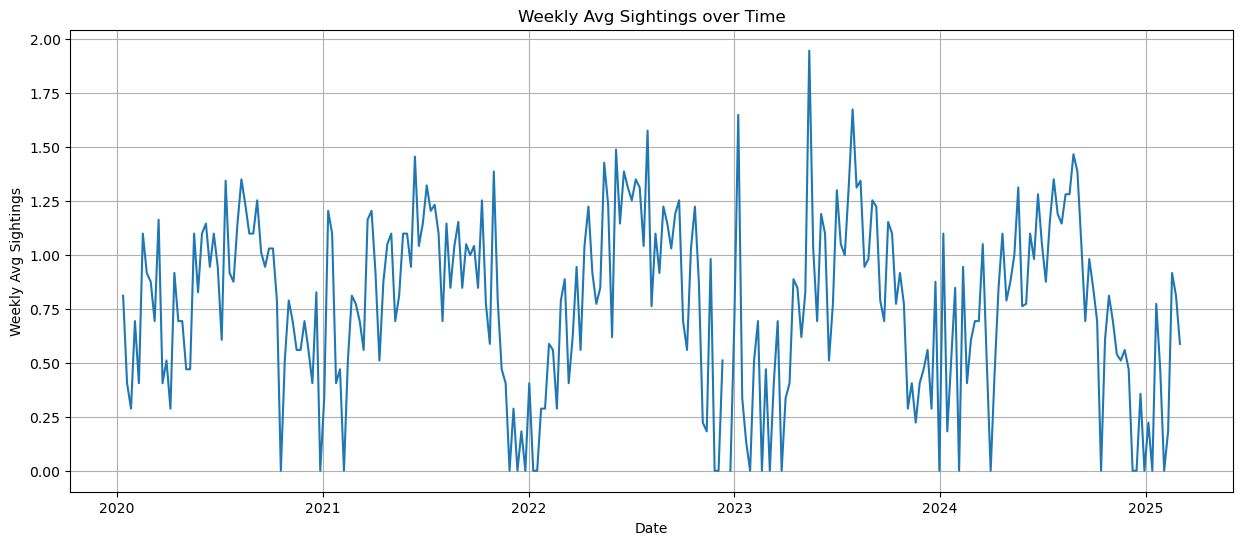

In [53]:
df = rs_weekly.copy()

df["ds"] = pd.to_datetime(df["ds"])

plt.figure(figsize=(15,6))
plt.plot(df["ds"], np.log(df["y"]))

plt.xlabel("Date")
plt.ylabel("Weekly Avg Sightings")
plt.title("Weekly Avg Sightings over Time")
plt.grid(True)

plt.show()

In [54]:
import torch
from torch.serialization import load as _real_torch_load

torch.load = lambda *args, **kwargs: _real_torch_load(
    *args, **{**kwargs, 'weights_only': False}
)

results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):

    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    train = train.dropna(subset=["y"])

    model = NeuralProphet(
        yearly_seasonality=True,
        weekly_seasonality=False,  # no sub-weekly patterns in weekly data
        epochs=40,
        accelerator='cpu',
        n_lags=4                   # 4 weekly lags ≈ 1 month
    )

    model = model.add_country_holidays(country_name="US")
    model.add_lagged_regressor('apparent_temperature_max', n_lags=4)  # 4 weeks

    model.fit(train, freq="W", progress="off")

    future = pd.concat([
        train[['ds', 'y'] + regressed_features],
        test[['ds', 'y']].merge(wd_merged[['ds'] + regressed_features], on="ds", how="left")
    ])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values

    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse_val, "mape": mape_val})

neural_prophet_weekly_results_df = pd.DataFrame(results)
neural_prophet_weekly_results_df.loc["mean"] = ["mean", neural_prophet_weekly_results_df["rmse"].mean(), neural_prophet_weekly_results_df["mape"].mean()]
neural_prophet_weekly_results_df

Finding best initial lr:   0%|          | 0/210 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 11it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/210 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Predicting: 17it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/214 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 17it [00:00, ?it/s]

,fold,rmse,mape
0,0,0.634429,0.440476
1,1,1.159172,0.527095
2,2,2.488914,0.651786
3,3,2.007815,0.717057
4,4,0.425252,0.109620
5,5,0.990960,0.231489
6,6,0.860394,0.260815
7,7,0.874007,0.271592
8,8,0.493007,0.277564
9,9,1.218093,0.633333


In [55]:
# forecast already has the right columns: yhat1, trend, seasonality etc.
print(forecast.columns.tolist())

# Plot directly from forecast (no get_latest_forecast needed)
fig1 = model.plot(forecast)
fig1.show()

# Plot components
fig2 = model.plot_components(forecast)
fig2.show()

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


['ds', 'y', 'yhat1', 'ar1', 'lagged_regressor_apparent_temperature_max1', 'trend', 'season_yearly', 'events_additive', 'event_Christmas Day', 'event_Christmas Day (observed)', 'event_Columbus Day', 'event_Independence Day', 'event_Independence Day (observed)', 'event_Juneteenth National Independence Day', 'event_Juneteenth National Independence Day (observed)', 'event_Labor Day', 'event_Martin Luther King Jr. Day', 'event_Memorial Day', "event_New Year's Day", "event_New Year's Day (observed)", 'event_Thanksgiving Day', 'event_Veterans Day', 'event_Veterans Day (observed)', "event_Washington's Birthday"]


ERROR - (NP.plotly.plot_components) - plotly-resampler is not installed. Please install it to use the resampler.


In [56]:
model.plot_parameters()

ERROR - (NP.plotly.plot_parameters) - plotly-resampler is not installed. Please install it to use the resampler.
